## 2. Exploratory Data Analysis (EDA)

In [63]:
import pandas as pd
import numpy as np

# load cleaned data
df_cleaned = pd.read_csv('../data/data_cleaned.csv', low_memory=False)
df_cleaned.shape

(3596, 12)

In [64]:
print(df_cleaned.head().to_string())

                               id        date                   titulaire-liste titulaire-profession titulaire-age-calcule titulaire-sexe departement-insee                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             

In [65]:
df_cleaned.columns

Index(['id', 'date', 'titulaire-liste', 'titulaire-profession',
       'titulaire-age-calcule', 'titulaire-sexe', 'departement-insee', 'text',
       'word_count', 'year', 'profession_clean', 'party_clean'],
      dtype='str')

In [66]:
# stats of word count of text
df_cleaned['word_count'].describe()

count    3596.000000
mean      637.065072
std       289.338109
min       130.000000
25%       464.000000
50%       555.000000
75%       784.000000
max      2765.000000
Name: word_count, dtype: float64

In [67]:
# party
df_cleaned["party_clean"].value_counts().head(15)

party_clean
Other                                          864
Liste d'entente populaire et nationale         450
Entente des écologistes                        421
Union pour une nouvelle majorité               350
Union du rassemblement et du centre            310
Majorité présidentielle pour la France unie    287
Rassemblement des forces de gauche             266
Majorité de la France                          172
Alliance des Français pour le progrès          155
Majorité d'union de la gauche                  140
Union pour la France                           126
Majorité présidentielle                         55
Name: count, dtype: int64

In [68]:
# profession
df_cleaned["profession_clean"].value_counts()

profession_clean
Other          1454
Education       617
Health          303
Business        300
Technical       278
Law             195
Worker          188
Agriculture     111
Political        95
Media            55
Name: count, dtype: int64

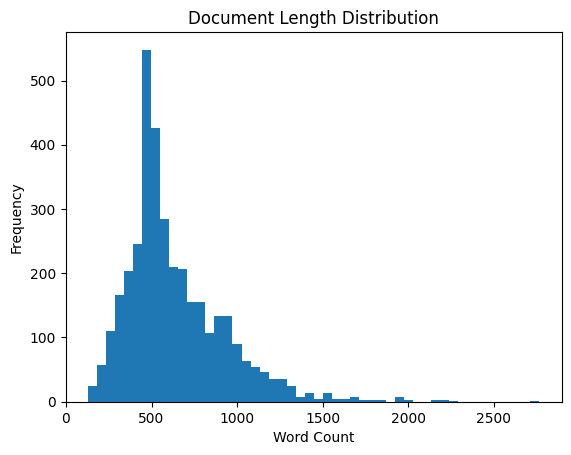

In [69]:
# distribution docs length
import matplotlib.pyplot as plt

plt.hist(df_cleaned['word_count'], bins=50)
plt.title("Document Length Distribution")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.show()

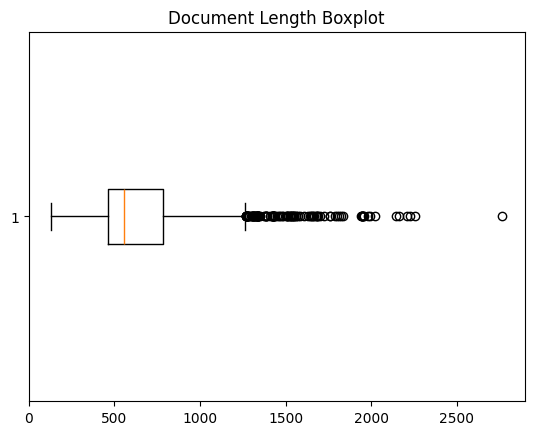

In [70]:
# boxplot of docs length
plt.boxplot(df_cleaned['word_count'], vert=False)
plt.title("Document Length Boxplot")
plt.show()

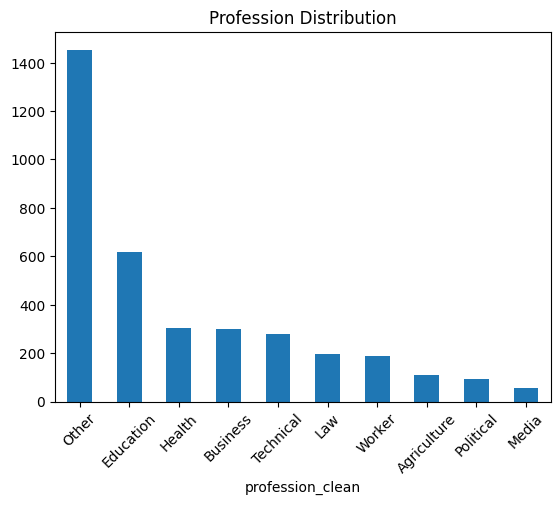

In [71]:
# distribution of profession
df_cleaned['profession_clean'].value_counts().plot(kind='bar')
plt.title("Profession Distribution")
plt.xticks(rotation=45)
plt.show()

### CountVectorizer

In [89]:
from sklearn.feature_extraction.text import CountVectorizer

# Initialize CountVectorizer
vectorizer = CountVectorizer()

# Fit and transform
X = vectorizer.fit_transform(df_cleaned['text'])

# Get words and counts
words = vectorizer.get_feature_names_out()
word_counts = np.array(X.sum(axis=0)).flatten()

# Combine and sort
freq = [(word, int(word_counts[i])) for i, word in enumerate(words)]
freq_sorted = sorted(freq, key=lambda x: x[1], reverse=True)

# Top 20
freq_sorted[:20]

[('de', 119942),
 ('la', 79654),
 ('et', 66050),
 ('le', 51351),
 ('les', 49450),
 ('des', 42129),
 ('pour', 38179),
 ('du', 29732),
 ('en', 21693),
 ('une', 20812),
 ('qui', 18598),
 ('est', 18266),
 ('un', 16456),
 ('que', 14947),
 ('dans', 14536),
 ('vous', 13818),
 ('nous', 13264),
 ('au', 13133),
 ('il', 12381),
 ('par', 11903)]

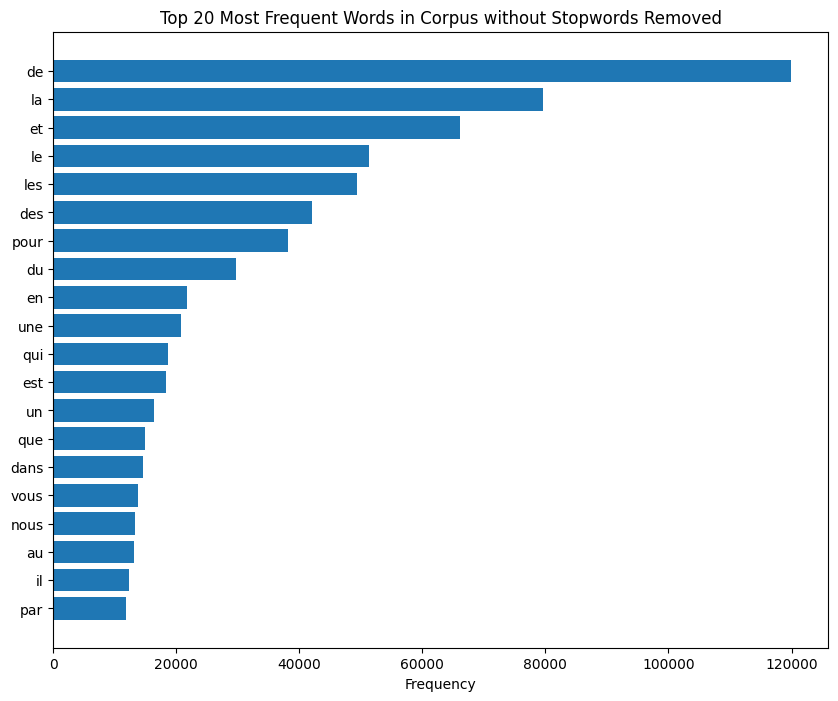

In [73]:
# Take top words
top_words = freq_sorted[:20]

words = [w[0] for w in top_words]
counts = [w[1] for w in top_words]

# Plot
plt.figure(figsize=(10,8))
plt.barh(words, counts)
plt.xlabel("Frequency")
plt.title("Top 20 Most Frequent Words in Corpus without Stopwords Removed")
plt.gca().invert_yaxis()
plt.show()

In [74]:
import nltk

# dowload french stopword 
nltk.download('stopwords', download_dir='./nltk_data')

[nltk_data] Downloading package stopwords to ./nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [75]:
from nltk.corpus import stopwords

# Load French stopwords
french_stopwords = stopwords.words('french')

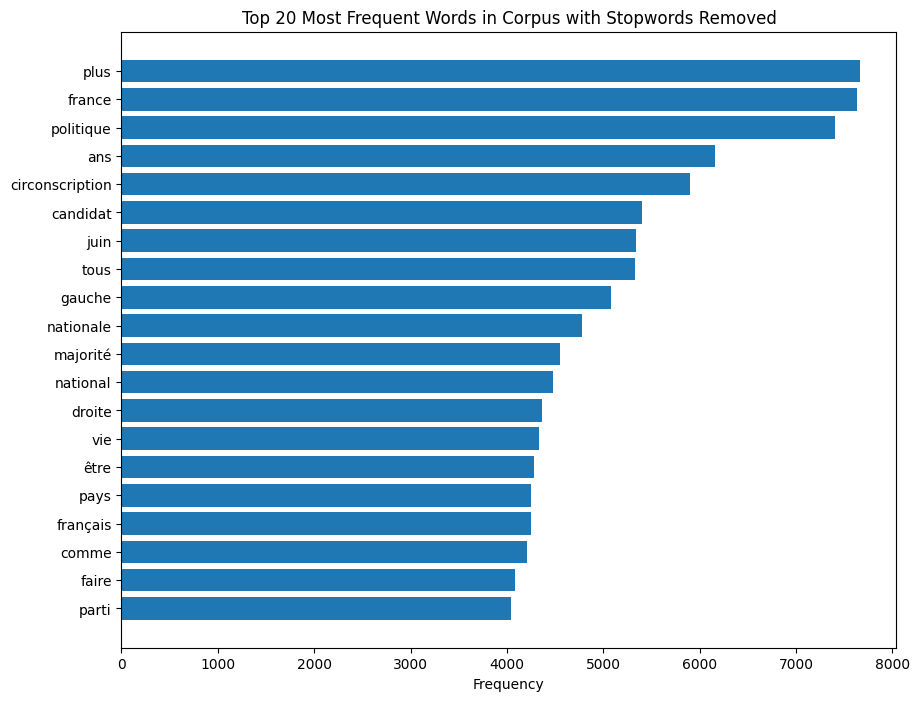

In [76]:
from sklearn.feature_extraction.text import CountVectorizer

# Initialize CountVectorizer
vectorizer = CountVectorizer(
    stop_words=french_stopwords,
    token_pattern=r'\b[a-zA-ZÀ-ÿ]{3,}\b',  # only words longer that letters and no numbers to prevent temporal when modeling
    max_df=0.95,
    min_df=20
)

# Fit and transform
X = vectorizer.fit_transform(df_cleaned['text'])

# Get words and counts
words = vectorizer.get_feature_names_out()
word_counts = np.array(X.sum(axis=0)).flatten()

# Combine and sort
freq = [(word, int(word_counts[i])) for i, word in enumerate(words)]
freq_sorted = sorted(freq, key=lambda x: x[1], reverse=True)

# Take top words
top_words = freq_sorted[:20]
words = [w[0] for w in top_words]
counts = [w[1] for w in top_words]

# Plot
plt.figure(figsize=(10,8))
plt.barh(words, counts)
plt.xlabel("Frequency")
plt.title("Top 20 Most Frequent Words in Corpus with Stopwords Removed")
plt.gca().invert_yaxis() 
plt.show()

In [77]:
# additional stopwords
extra_stopwords = {

    # Archive artifacts
    "cevipof","fonds",

    # Election formatting
    "circonscription","elections","législatives","juin","mars","tour",

    # Candidate biography
    "candidat","candidats","conseiller","député","président",
    "maire","suppléant","jean","michel","ans",

    # Weak rhetorical words
    "comme","contre","faire","fait","faut","plus",
    "cette","ceux","leurs","depuis","tout","tous",
    "être", "falloir", "vouloir", "donner",

    # German OCR artifacts
    "die","der","und","für","den","sie","eine","das","wir","werden",'auf', 'nicht', 
    'einer', 'dass', 'alsace', 'strasbourg', 'gegen', 'ihr', 'wählen', 'wollen', 'auch',
    "mit","von","ist","dem","ein","ich","sich","wird","haben","durch","ihre",

    # Additional formatting / weak tokens seen in topics
    "mai","général","toutes"
}

french_stopwords = set(stopwords.words('french'))

# Combine standard and extra stopwords
all_stopwords = list(french_stopwords.union(extra_stopwords))

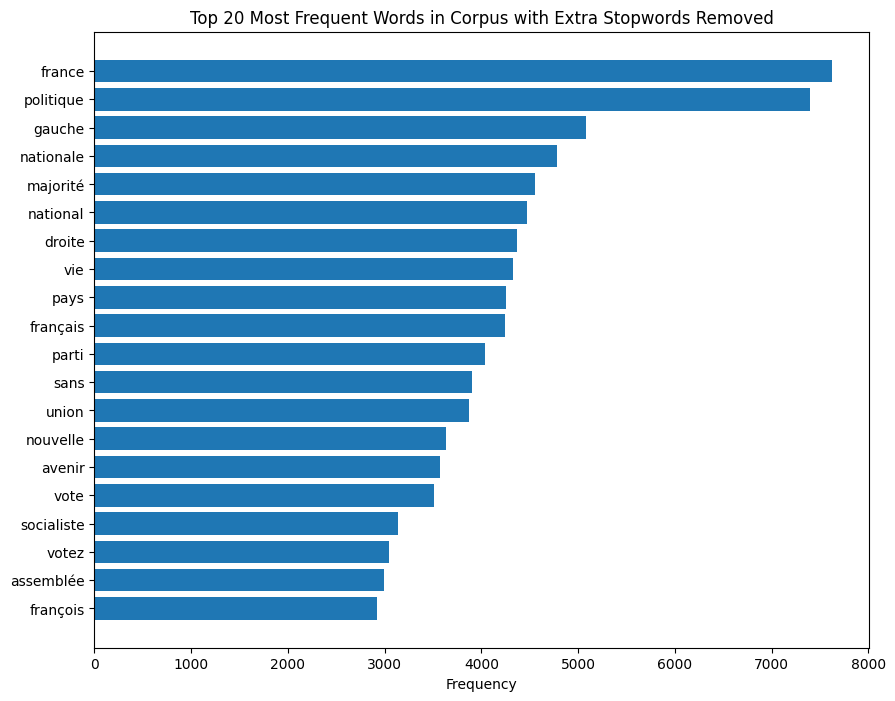

In [78]:
from sklearn.feature_extraction.text import CountVectorizer

# Initialize CountVectorizer
vectorizer = CountVectorizer(
    stop_words=all_stopwords,
    token_pattern=r'\b[a-zA-ZÀ-ÿ]{3,}\b',  # only words longer that letters and no numbers to prevent temporal when modeling
    max_df=0.95,
    min_df=20
)

# Fit and transform
X = vectorizer.fit_transform(df_cleaned['text'])

# Get words and counts
words = vectorizer.get_feature_names_out()
word_counts = np.array(X.sum(axis=0)).flatten()

# Combine and sort
freq = [(word, int(word_counts[i])) for i, word in enumerate(words)]
freq_sorted = sorted(freq, key=lambda x: x[1], reverse=True)

# Take top words
top_words = freq_sorted[:20]
words = [w[0] for w in top_words]
counts = [w[1] for w in top_words]

# Plot
plt.figure(figsize=(10,8))
plt.barh(words, counts)
plt.xlabel("Frequency")
plt.title("Top 20 Most Frequent Words in Corpus with Extra Stopwords Removed")
plt.gca().invert_yaxis() 
plt.show()

#### Lemmatization

In [80]:
import spacy
# !python -m spacy download fr_core_news_md

nlp = spacy.load("fr_core_news_md")

def lemmatize_text(text):
    doc = nlp(text)
    return " ".join([token.lemma_ for token in doc if not token.is_stop and token.is_alpha])

df_cleaned["text_lemma"] = df_cleaned["text"].apply(lemmatize_text)

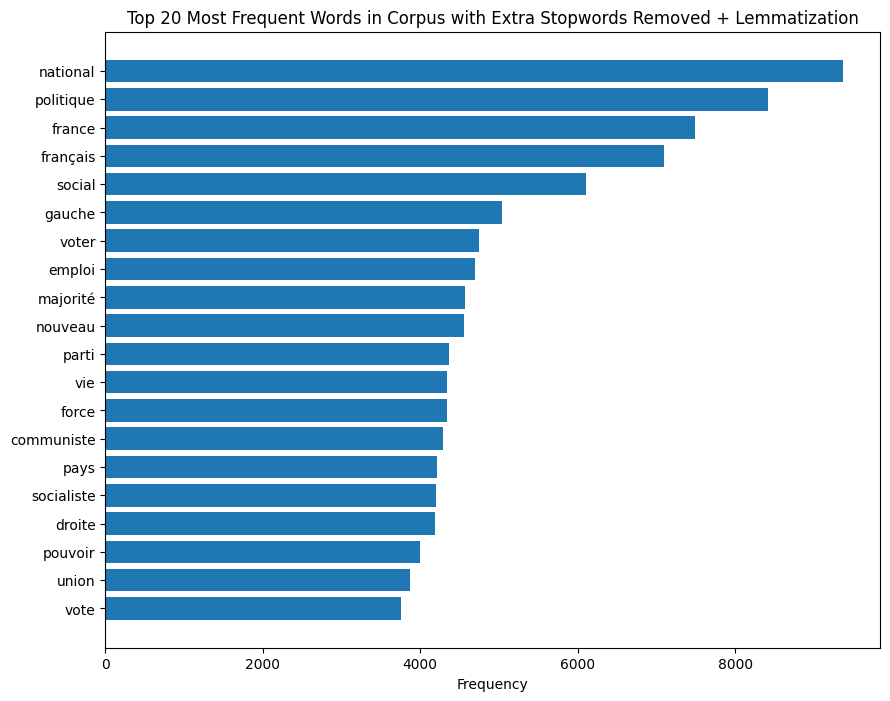

In [81]:
# Initialize CountVectorizer
vectorizer = CountVectorizer(
    stop_words=all_stopwords,
    token_pattern=r'\b[a-zA-ZÀ-ÿ]{3,}\b',  # only words longer that letters and no numbers to prevent temporal when modeling
    max_df=0.95,
    min_df=20
)

# Fit and transform
X = vectorizer.fit_transform(df_cleaned['text_lemma'])

# Get words and counts
words = vectorizer.get_feature_names_out()
word_counts = np.array(X.sum(axis=0)).flatten()

# Combine and sort
freq = [(word, int(word_counts[i])) for i, word in enumerate(words)]
freq_sorted = sorted(freq, key=lambda x: x[1], reverse=True)

# Take top words
top_words = freq_sorted[:20]
words = [w[0] for w in top_words]
counts = [w[1] for w in top_words]

# Plot
plt.figure(figsize=(10,8))
plt.barh(words, counts)
plt.xlabel("Frequency")
plt.title("Top 20 Most Frequent Words in Corpus with Extra Stopwords Removed + Lemmatization")
plt.gca().invert_yaxis() 
plt.show()



In [82]:
# Retrieve full vocabulary
vocab = vectorizer.get_feature_names_out()

# Top parties
top_parties = df_cleaned['party_clean'].value_counts().head(5).index

for party in top_parties:
    
    idx = (df_cleaned['party_clean'] == party).values
    
    mean_counts = X[idx].mean(axis=0)
    
    sorted_indices = np.argsort(mean_counts.A1)[::-1][:15]
    
    print("\nParty:", party)
    print([vocab[i] for i in sorted_indices])


Party: Other
['politique', 'gauche', 'social', 'français', 'national', 'france', 'emploi', 'droite', 'nouveau', 'parti', 'pouvoir', 'vie', 'voter', 'communiste', 'majorité']

Party: Liste d'entente populaire et nationale
['national', 'front', 'vote', 'français', 'avenir', 'force', 'rpr', 'udf', 'voter', 'france', 'vif', 'confiance', 'populaire', 'conviction', 'suppression']

Party: Entente des écologistes
['écologie', 'entente', 'écologiste', 'vie', 'politique', 'environnement', 'ecologie', 'nouveau', 'verts', 'humain', 'assemblée', 'ecologiste', 'homme', 'génération', 'generation']

Party: Union pour une nouvelle majorité
['liberté', 'france', 'majorité', 'socialiste', 'politique', 'union', 'national', 'français', 'social', 'nouvelle', 'communiste', 'pouvoir', 'société', 'parti', 'enfant']

Party: Union du rassemblement et du centre
['union', 'france', 'centre', 'national', 'rassemblement', 'socialiste', 'français', 'pouvoir', 'politique', 'homme', 'social', 'emploi', 'parti', 'enfan

### TfidfVectorizer

In [83]:
# get top parties
top_parties = df_cleaned['party_clean'].value_counts().head().index
top_parties

Index(['Other', 'Liste d'entente populaire et nationale',
       'Entente des écologistes', 'Union pour une nouvelle majorité',
       'Union du rassemblement et du centre'],
      dtype='str', name='party_clean')

In [84]:
# only top 6 parties
df_top = df_cleaned[df_cleaned['party_clean'].isin(top_parties)]

In [87]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TfidfVectorizer
tfidf = TfidfVectorizer(
    stop_words=all_stopwords,
    token_pattern=r'\b[a-zA-ZÀ-ÿ]{3,}\b',  # removes numbers & short tokens
    max_df=0.9,
    min_df=10
)

# Fit and transform the text data
X_tfidf = tfidf.fit_transform(df_top['text_lemma'])
terms = tfidf.get_feature_names_out()

# Get feature names and their corresponding TF-IDF scores
tfidf_scores = np.array(X_tfidf.sum(axis=0)).flatten()
tfidf_freq = [(terms[i], round(float(tfidf_scores[i]), 2)) for i in range(len(terms))]
tfidf_freq_sorted = sorted(tfidf_freq, key=lambda x: x[1], reverse=True)

# Top 20 TF-IDF terms
tfidf_freq_sorted[:20]

[('national', 198.32),
 ('front', 141.17),
 ('français', 117.58),
 ('vote', 112.15),
 ('politique', 104.18),
 ('france', 93.13),
 ('écologie', 90.12),
 ('voter', 84.03),
 ('rpr', 83.4),
 ('udf', 82.67),
 ('avenir', 80.45),
 ('force', 80.24),
 ('vie', 76.24),
 ('entente', 74.7),
 ('union', 72.9),
 ('écologiste', 71.78),
 ('social', 71.57),
 ('nouveau', 68.9),
 ('gauche', 66.8),
 ('socialiste', 66.39)]

In [88]:
# Analyze top TF-IDF terms for each party
for party in top_parties:
    idx = (df_top['party_clean'] == party).values
    mean_tfidf = X_tfidf[idx].mean(axis=0)
    sorted_indices = np.argsort(mean_tfidf.A1)[::-1][:15]
    print("\nParty:", party)
    print([terms[i] for i in sorted_indices])


Party: Other
['gauche', 'politique', 'droite', 'communiste', 'majorité', 'parti', 'français', 'social', 'france', 'pouvoir', 'vie', 'national', 'homme', 'emploi', 'monsieur']

Party: Liste d'entente populaire et nationale
['national', 'front', 'vote', 'rpr', 'udf', 'français', 'vif', 'avenir', 'liste', 'conviction', 'suppression', 'force', 'ici', 'populaire', 'électeur']

Party: Entente des écologistes
['écologie', 'entente', 'écologiste', 'environnement', 'ecologie', 'ecologiste', 'verts', 'humain', 'vie', 'generation', 'ecologistes', 'génération', 'chance', 'politique', 'vert']

Party: Union pour une nouvelle majorité
['majorité', 'nouvelle', 'liberté', 'communiste', 'socialiste', 'union', 'france', 'politique', 'parti', 'changement', 'société', 'non', 'français', 'pouvoir', 'national']

Party: Union du rassemblement et du centre
['centre', 'union', 'rassemblement', 'france', 'socialiste', 'ouverture', 'pouvoir', 'national', 'monsieur', 'français', 'parti', 'formation', 'homme', 'en